# Retrospective Evaluation on Complex Cases

Contact adamperer@cmu.edu and venkatesh.sivaraman.98@gmail.com for access to the transformed MIMIC-IV data and model weights needed to run this script. The aggregated outputs of running the script on the data are shown below.

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import tqdm
import gzip
import json

import matplotlib
import pickle

import torch

from sklearn.manifold import TSNE

import sys; sys.path.insert(0, '..')
from sepsis_models.models.autoencoder import *
from sepsis_models.preprocessing.dataset import *
from sepsis_models.derived_information.neighbors import get_nearest_neighbors
from sepsis_models.derived_information.predictive import PredictiveActionDependentInformation
from sepsis_models.derived_information.prescriptive import PrescriptiveOutcomeInformation
from sepsis_models.derived_information.patient_info import create_state_dict, demog_features, state_features
from sepsis_models.derived_information.utils import TREATMENT_INFO
from utils import convert_to_native_types

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

data_dir = "data"
model_dir = "model_weights"

In [3]:
AS_IS_COLUMNS = []
LOG_NORM_COLUMNS = [
    "SpO2", "BUN", "Creatinine", "AST", "ALT", 
    "Total Bili", "Direct Bili", "INR", "Input Last 24 h", "Output Last 24 h",
    "Hypertonic Crystalloid", "Hypotonic Crystalloid", "Isotonic Crystalloid",
    "Blood Products", "Isotonic Colloid",
    "Dopamine", "Epinephrine", "Norepinephrine", "Vasopressin", "Phenylephrine"
]

COMORBIDITIES = [
    'congestive_heart_failure', 'cardiac_arrhythmias', 'valvular_disease',
    'pulmonary_circulation', 'peripheral_vascular', 'hypertension',
    'paralysis', 'other_neurological', 'chronic_pulmonary',
    'diabetes_uncomplicated', 'diabetes_complicated', 'hypothyroidism',
    'renal_failure', 'liver_disease', 'peptic_ulcer',
    'aids', 'lymphoma', 'metastatic_cancer',
    'solid_tumor', 'rheumatoid_arthritis', 'coagulopathy',
    'obesity', 'weight_loss', 'fluid_electrolyte',
    'blood_loss_anemia', 'deficiency_anemias', 'alcohol_abuse',
    'drug_abuse', 'psychoses', 'depression'
]

EXCLUDE_COLUMNS = []

def format_states(df, scaler=None, all_columns=None):
    global AS_IS_COLUMNS, LOG_NORM_COLUMNS, EXCLUDE_COLUMNS
    dummies = pd.get_dummies(df, 
                        columns=[c for c in df.columns 
                                if pd.api.types.is_object_dtype(df[c].dtype) 
                                or pd.api.types.is_string_dtype(df[c].dtype) 
                                or isinstance(df[c].dtype, pd.CategoricalDtype)])
    if all_columns is not None:
        dummies = dummies.assign(**{c: np.zeros(len(dummies), dtype=np.uint8)
                                    for c in all_columns if c not in dummies.columns})
    if scaler is None:
        EXCLUDE_COLUMNS = [c for c in dummies.columns
                           if (('O2 Delivery Device' in c or c.startswith("Heart Rhythm")) and dummies[c].mean() < 0.01) or
                           c.endswith("Present")]
        dummies = dummies.drop(columns=EXCLUDE_COLUMNS)
        AS_IS_COLUMNS = ["id", "intime", "Invasive Ventilation", "Non-invasive Ventilation",
                 *[c for c in dummies.columns 
                   if "_" in c or 
                   " Present" in c or 
                   c.endswith("Current") or 
                   c.endswith("Ever") or 
                   (c.startswith("Positive") and c.endswith("Culture")) or 
                   c in COMORBIDITIES]]
        
        scaler = DataNormalization(dummies,
                                      as_is_columns=AS_IS_COLUMNS,
                                      log_norm_columns=LOG_NORM_COLUMNS,
                                      norm_columns=[c for c in dummies.columns if c not in AS_IS_COLUMNS + LOG_NORM_COLUMNS])
        return scaler.transform(dummies).assign(id=dummies['id'], intime=dummies['intime']), scaler, dummies.columns
    return scaler.transform(dummies.drop(columns=[c for c in EXCLUDE_COLUMNS if c in dummies.columns])).assign(id=dummies['id'], intime=dummies['intime'])
    
def create_treatments(split, past=False, encode=False):
    treatments = pd.concat([
        pd.read_csv(os.path.join(data_dir, "past_treatments" if past else "treatments", "fluids", f"{split}.csv"), index_col=0),
        pd.read_csv(os.path.join(data_dir, "past_treatments" if past else "treatments", "vaso", f"{split}.csv"), index_col=0).drop(columns=["id", "intime"]),
    ], axis=1)
    treatments.columns = ["id", "intime", "fluid", "vaso"]
    treatments['vaso'] = treatments['vaso'].fillna(0).astype(int)
    treatments['fluid'] = treatments['fluid'].fillna(0).astype(int)
    # if past:
    #     treatments['fluid'] = treatments['fluid'].groupby(treatments["id"]).shift(1)
    #     treatments['vaso'] = treatments['vaso'].groupby(treatments["id"]).shift(1)
    if encode:
        return treatments['fluid'] * 3 + treatments['vaso']
    return treatments.drop(columns=["id", "intime"])

train_df, normalizer, all_cols = format_states(pd.read_csv(os.path.join(data_dir, "model_features", "inputs_train.csv"), index_col=0))
train_df = train_df.clip(-10, 10).assign(id=train_df['id'], intime=train_df['intime'])
val_df = format_states(pd.read_csv(os.path.join(data_dir, "model_features", "inputs_val.csv"), index_col=0), scaler=normalizer, all_columns=all_cols)
val_df = val_df.clip(-10, 10).assign(id=val_df['id'], intime=val_df['intime'])
test_df = format_states(pd.read_csv(os.path.join(data_dir, "model_features", "inputs_test.csv"), index_col=0), scaler=normalizer, all_columns=all_cols)
test_df = test_df.clip(-10, 10).assign(id=test_df['id'], intime=test_df['intime'])
print("Excluding columns:", EXCLUDE_COLUMNS)

train_uo = pd.read_csv(os.path.join(data_dir, "filters", "uo", "train.csv"), index_col=0).values[:,-1]
val_uo = pd.read_csv(os.path.join(data_dir, "filters", "uo", "val.csv"), index_col=0).values[:,-1]
test_uo = pd.read_csv(os.path.join(data_dir, "filters", "uo", "test.csv"), index_col=0).values[:,-1]
train_cmo = pd.read_csv(os.path.join(data_dir, "filters", "cmo", "train.csv"), index_col=0).values[:,-1]
val_cmo = pd.read_csv(os.path.join(data_dir, "filters", "cmo", "val.csv"), index_col=0).values[:,-1]
test_cmo = pd.read_csv(os.path.join(data_dir, "filters", "cmo", "test.csv"), index_col=0).values[:,-1]

# filter inputs to exclude patients who have less than 1 urine observation per day on average
train_mask = ~train_uo.astype(bool) & ~train_cmo.astype(bool) # pd.isna(train_y).groupby(train_df['id']).transform("sum") < max_missing
val_mask = ~val_uo.astype(bool) & ~val_cmo.astype(bool) # pd.isna(val_y).groupby(val_df['id']).transform("sum") < max_missing
test_mask = ~test_uo.astype(bool) & ~test_cmo.astype(bool) # pd.isna(test_y).groupby(test_df['id']).transform("sum") < max_missing

# CHANGED HERE: include only up to 7 days per patient
max_steps = np.round(np.quantile(train_df.groupby('id').size(), 0.95)) # 42
print('max steps:', max_steps)
min_days = 0.5
time_res = 4
train_mask &= ((train_df['intime'].groupby(train_df['id']).transform(lambda g: np.argsort(g)) < max_steps)
              & (pd.Series(train_mask, index=train_df.index).groupby(train_df['id']).transform("sum") >= min_days * 24 / time_res))
val_mask &= ((val_df['intime'].groupby(val_df['id']).transform(lambda g: np.argsort(g)) < max_steps)
            & (pd.Series(val_mask, index=val_df.index).groupby(val_df['id']).transform("sum") >= min_days * 24 / time_res))
test_mask &= ((test_df['intime'].groupby(test_df['id']).transform(lambda g: np.argsort(g)) < max_steps)
             & (pd.Series(test_mask, index=test_df.index).groupby(test_df['id']).transform("sum") >= min_days * 24 / time_res))

# CHANGED: remove patients who never receive any treatment
treatments_train = create_treatments('train')
treatments_val = create_treatments('val')
treatments_test = create_treatments('test')
# train_mask &= ~((treatments_train['fluid'] == 0) & (treatments_train['vaso'] == 0)).groupby(train_df['id']).transform('all')
# val_mask &= ~((treatments_val['fluid'] == 0) & (treatments_val['vaso'] == 0)).groupby(val_df['id']).transform('all')
# test_mask &= ~((treatments_test['fluid'] == 0) & (treatments_test['vaso'] == 0)).groupby(test_df['id']).transform('all')

# TEMPORARY: sample test IDs
# np.random.seed(1234)
# test_sample_ids = np.random.choice(test_df['id'].unique(), size=2000, replace=False)
# test_mask &= test_df['id'].isin(test_sample_ids)

dup_counts = test_df.loc[test_df.duplicated([c for c in test_df.columns if c not in ("intime",)]), 'id'].value_counts()
print("Excluding patients with more than 3 duplicated rows:", test_df[test_df['id'].isin(dup_counts[dup_counts >= 3].index)]['id'].unique())
test_mask &= ~test_df['id'].isin(dup_counts[dup_counts >= 3].index)

print("Before:", len(train_df), len(val_df), len(test_df))
train_df = train_df[train_mask].reset_index(drop=True)
val_df = val_df[val_mask].reset_index(drop=True)
test_df = test_df[test_mask].reset_index(drop=True)

treatments_train = treatments_train[train_mask].reset_index(drop=True)
treatments_val = treatments_val[val_mask].reset_index(drop=True)
treatments_test = treatments_test[test_mask].reset_index(drop=True)

print(len(train_df), len(val_df), len(test_df))

Excluding columns: ['ALT Present', 'AST Present', 'Arterial BE Present', 'Arterial pH Present', 'BUN Present', 'Bicarbonate Present', 'CO2 Calc Present', 'CVP Present', 'Calcium Present', 'Chloride Present', 'Creatinine Present', 'DiaBP Present', 'Direct Bili Present', 'FiO2 Present', 'GCS Eye Opening Present', 'GCS Motor Response Present', 'GCS Verbal Response Present', 'Glucose Present', 'Heart Rate Present', 'Hematocrit Present', 'Hemoglobin Present', 'INR Present', 'Ionized Ca Present', 'Lactic Acid Present', 'Magnesium Present', 'Mean Airway Pressure Present', 'Minute Volume Present', 'O2 Flow Present', 'PAPdia Present', 'PAPmean Present', 'PAPsys Present', 'PEEP Present', 'PT Present', 'PTT Present', 'PaCO2 Present', 'PaO2 Present', 'Peak Inspiratory Pressure Present', 'Plateau Pressure Present', 'Platelet Count Present', 'Potassium Present', 'RASS Present', 'Respiratory Rate Present', 'Sodium Present', 'SpO2 Present', 'SysBP Present', 'Temperature C Present', 'Tidal Volume Prese

In [4]:
# Number of trajectories seen during training
train_df['id'].nunique() + val_df['id'].nunique()

21065

In [5]:
best_param_set = {'architecture': 'transformer', 
                  'nencoder': 4, 
                  'nhead': 8, 
                  'nhid': 128, 
                  'nembed': 32, 
                  'lr': 0.001, 
                  'dropout': 0.1, 
                  'lr_decay': 0.98, 
                  'n_warmup': 4, 
                  'mask_gamma': 1.01}

model_trainer = TimeSeriesAutoencoderTrainer(
    train_df,
    val_df,
    test_df,
    time_col='intime',
    device='cpu',
    first_value_reconstruction=True,
    past_value_reconstruction=True,
    checkpoint_path=os.path.join(model_dir, f"weighted_transformer.pt"),
    **best_param_set
)

# model_trainer.fit(epochs=50, patience=200, batch_size=32)
model_trainer.load_checkpoint()

In [7]:
past_treatments_train = create_treatments('train', past=True, encode=True)[train_mask]
past_treatments_val = create_treatments('val', past=True, encode=True)[val_mask]
past_treatments_test = create_treatments('test', past=True, encode=True)[test_mask]

In [8]:
# example: nearest neighbors of the validation set instances in the training set
neighborhoods_dir = os.path.join(data_dir, "neighborhoods")
if not os.path.exists(neighborhoods_dir): os.mkdir(neighborhoods_dir)

if not os.path.exists(os.path.join(neighborhoods_dir, "train_neighbors.pkl")):
    train_encoded = model_trainer.encode(model_trainer.train_dataset)
    val_encoded = model_trainer.encode(model_trainer.val_dataset)
    test_encoded = model_trainer.encode(model_trainer.test_dataset)
    train_neighb_train, train_neighb_dist_train = get_nearest_neighbors(train_encoded, 
                                                                    train_encoded, 
                                                                    train_df["id"].values, 
                                                                    reference_identical=True,
                                                                    stratify=(past_treatments_train, past_treatments_train))
    val_neighb_train, val_neighb_dist_train = get_nearest_neighbors(val_encoded, 
                                                                    train_encoded, 
                                                                    train_df["id"].values, 
                                                                    stratify=(past_treatments_val, past_treatments_train))
    test_neighb_train, test_neighb_dist_train = get_nearest_neighbors(test_encoded, 
                                                                    train_encoded, 
                                                                    train_df["id"].values, 
                                                                    stratify=(past_treatments_test, past_treatments_train))

    with open(os.path.join(neighborhoods_dir, "train_neighbors.pkl"), "wb") as file:
        pickle.dump((train_neighb_train, train_neighb_dist_train), file)
    with open(os.path.join(neighborhoods_dir, "val_neighbors.pkl"), "wb") as file:
        pickle.dump((val_neighb_train, val_neighb_dist_train), file)
    with open(os.path.join(neighborhoods_dir, "test_neighbors.pkl"), "wb") as file:
        pickle.dump((test_neighb_train, test_neighb_dist_train), file)
else:
    with open(os.path.join(neighborhoods_dir, "train_neighbors.pkl"), "rb") as file:
        train_neighb_train, train_neighb_dist_train = pickle.load(file)
    with open(os.path.join(neighborhoods_dir, "val_neighbors.pkl"), "rb") as file:
        val_neighb_train, val_neighb_dist_train = pickle.load(file)
    with open(os.path.join(neighborhoods_dir, "test_neighbors.pkl"), "rb") as file:
        test_neighb_train, test_neighb_dist_train = pickle.load(file)
    

In [9]:
severity_scores_train = pd.read_csv(os.path.join(data_dir, "outcomes", "sofa", "train.csv"), index_col=0).iloc[:,-1].values
severity_scores_train = severity_scores_train[train_mask]
severity_scores_val = pd.read_csv(os.path.join(data_dir, "outcomes", "sofa", "val.csv"), index_col=0).iloc[:,-1].values
severity_scores_val = severity_scores_val[val_mask]
severity_scores_test = pd.read_csv(os.path.join(data_dir, "outcomes", "sofa", "test.csv"), index_col=0).iloc[:,-1].values
severity_scores_test = severity_scores_test[test_mask]

severity_cutoffs = np.quantile(severity_scores_train, np.linspace(0, 1, 9))
print("SOFA score cutoffs:", severity_cutoffs)
train_severity_quantiles = np.digitize(severity_scores_train, severity_cutoffs[:-1]) - 1
val_severity_quantiles = np.digitize(severity_scores_val, severity_cutoffs[:-1]) - 1
test_severity_quantiles = np.digitize(severity_scores_test, severity_cutoffs[:-1]) - 1

SOFA score cutoffs: [ 0.  4.  5.  6.  7.  8.  9. 11. 23.]


# Weighted Importance Sampling

First train two XGBoost models: one to predict the probability of each possible treatment given all the covariates, and another to predict the same thing given only the constant features. Then we calculate the probabilities of being equal to the AI recommended treatment for each step.

In [10]:
import xgboost

tx_flattener = lambda t: t['fluid'] * 3 + t['vaso']
flattened_treatments_train = pd.DataFrame(tx_flattener(treatments_train))
flattened_treatments_val = pd.DataFrame(tx_flattener(treatments_val))
flattened_treatments_test = pd.DataFrame(tx_flattener(treatments_test))

all_inputs_train = train_df.drop(columns=['id', 'intime'])
all_tx_outputs_train = flattened_treatments_train
all_inputs_val = val_df.drop(columns=['id', 'intime'])
all_tx_outputs_val = flattened_treatments_val
all_inputs_test = test_df.drop(columns=['id', 'intime'])
all_tx_outputs_test = flattened_treatments_test
print(all_inputs_train.shape, all_tx_outputs_train.shape)
print(all_inputs_val.shape, all_tx_outputs_val.shape)
print(all_inputs_test.shape, all_tx_outputs_test.shape)

(391946, 185) (391946, 1)
(202905, 185) (202905, 1)
(195584, 185) (195584, 1)


In [11]:
if os.path.exists(os.path.join(model_dir, "260804_all_tx_xgb.json")):
    all_tx_model = xgboost.XGBClassifier()
    all_tx_model.load_model(os.path.join(model_dir, "260804_all_tx_xgb.json"))
else:
    all_tx_model = xgboost.XGBClassifier()
    all_tx_model.fit(all_inputs_train, all_tx_outputs_train)
    all_tx_model.save_model(os.path.join(model_dir, "260804_all_tx_xgb.json"))
print("With all covariates:", all_tx_model.score(all_inputs_val, all_tx_outputs_val))

With all covariates: 0.7767526675044972


In [12]:
# Get the recommended outputs for each instance. Some timesteps have no recommendation
# because none of the treatment actions were taken frequently enough - exclude these
train_outcome = pd.read_csv(os.path.join(data_dir, "outcomes", "morta", "train.csv"), index_col=0).iloc[:,-1].values[train_mask]
ai_clinician = PrescriptiveOutcomeInformation(train_neighb_train, 
                                              train_df['id'].astype(int), 
                                              train_outcome, 
                                              treatments_train.values, 
                                              severity_cutoffs)

all_plan_model = PredictiveActionDependentInformation(train_neighb_train, 
                                              train_df['id'].astype(int), 
                                              train_outcome, 
                                              treatments_train.values, 
                                              severity_cutoffs)

recs_val = []
plans_val = []
recs_test = []
plans_test = []
for i in tqdm.tqdm(range(len(val_df))):
    rec = ai_clinician.get_recommendation(
                            val_neighb_train[i], 
                            val_severity_quantiles[i])
    if not rec: 
        print(i, rec)
        assert False
    else:
        recs_val.append({
            'fluid': TREATMENT_INFO[0]['short_names'].index(rec['recommendation'][0]['value']),
            'vaso': TREATMENT_INFO[1]['short_names'].index(rec['recommendation'][1]['value'])
        })
        plans = all_plan_model.get_prediction(
                            val_neighb_train[i], 
                            val_severity_quantiles[i], min_frequency=0.05)
        plan_fluids = np.array([TREATMENT_INFO[0]['short_names'].index(p['policy'][0]['value']) for p in plans['predictions']])
        plan_vaso = np.array([TREATMENT_INFO[1]['short_names'].index(p['policy'][1]['value']) for p in plans['predictions']])
        plans_val.append({
            f * 3 + v: 1
            for f, v in zip(plan_fluids, plan_vaso)
        })
for i in tqdm.tqdm(range(len(test_df))):
    rec = ai_clinician.get_recommendation(
                            test_neighb_train[i], 
                            test_severity_quantiles[i])
    if not rec: 
        # recs_test.append({'fluid': None, 'vaso': None})
        # plans_test.append({})
        print(i, rec)
        assert False
    else:
        recs_test.append({
            'fluid': TREATMENT_INFO[0]['short_names'].index(rec['recommendation'][0]['value']),
            'vaso': TREATMENT_INFO[1]['short_names'].index(rec['recommendation'][1]['value'])
        })
        plans = all_plan_model.get_prediction(
                            test_neighb_train[i], 
                            test_severity_quantiles[i], min_frequency=0.05)
        plan_fluids = np.array([TREATMENT_INFO[0]['short_names'].index(p['policy'][0]['value']) for p in plans['predictions']])
        plan_vaso = np.array([TREATMENT_INFO[1]['short_names'].index(p['policy'][1]['value']) for p in plans['predictions']])
        plans_test.append({
            f * 3 + v: 1
            for f, v in zip(plan_fluids, plan_vaso)
        })
recs_val = tx_flattener(pd.DataFrame(recs_val))
recs_test = tx_flattener(pd.DataFrame(recs_test))
plans_val = pd.DataFrame(plans_val)
plans_test = pd.DataFrame(plans_test)
print(recs_val.value_counts(), plans_val.mean(axis=0))

  1%|          | 1556/202905 [00:00<01:05, 3077.66it/s]/Users/vsivaram/miniconda3/envs/sepsis-ai/lib/python3.11/site-packages/statsmodels/stats/weightstats.py:792: RuntimeWarning: invalid value encountered in scalar divide
  zstat = value / std
100%|██████████| 195584/195584 [01:02<00:00, 3143.84it/s]


0     63639
9     57663
3     50387
1      8546
4      8498
10     3811
5      3711
6      2139
7      1755
2      1389
8      1061
11      306
Name: count, dtype: int64 1     1.0
3     1.0
4     1.0
6     1.0
7     1.0
0     1.0
9     1.0
10    1.0
5     1.0
8     1.0
11    1.0
2     1.0
dtype: float64


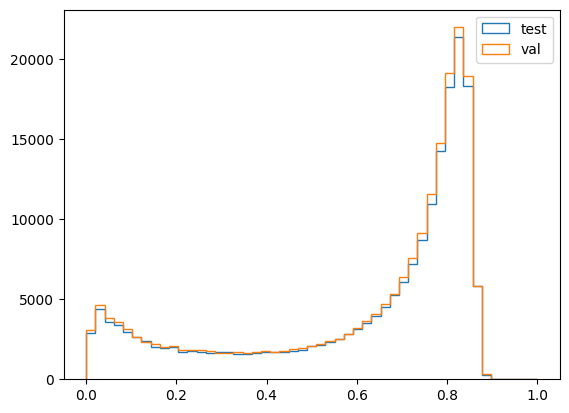

In [13]:
# Calculate probability according to clinician policy of taking each action
all_treatment_probs_val = all_tx_model.predict_proba(all_inputs_val)
all_treatment_probs_val = all_treatment_probs_val + 0.01
all_treatment_probs_val /= all_treatment_probs_val.sum(axis=1, keepdims=True)
all_treatment_probs_val = all_treatment_probs_val[np.arange(len(all_tx_outputs_val)),all_tx_outputs_val.values.astype(int).flatten()]

all_treatment_probs_test = all_tx_model.predict_proba(all_inputs_test)
all_treatment_probs_test = all_treatment_probs_test + 0.01
all_treatment_probs_test /= all_treatment_probs_test.sum(axis=1, keepdims=True)
all_treatment_probs_test = all_treatment_probs_test[np.arange(len(all_tx_outputs_test)),all_tx_outputs_test.values.astype(int).flatten()]

plt.figure()
plt.hist(all_treatment_probs_test, bins=np.linspace(0, 1, 50), histtype='step', label='test')
plt.hist(all_treatment_probs_val, bins=np.linspace(0, 1, 50), histtype='step', label='val')
plt.legend()
plt.show()

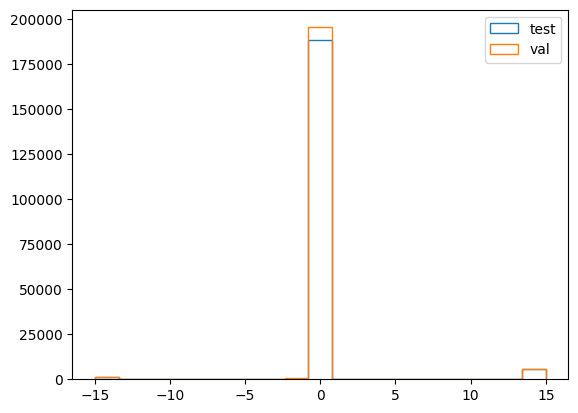

In [14]:
# following https://arxiv.org/pdf/2101.08477, which follows Raghu et al

MORTA_REWARD = -15
SURVIVAL_REWARD = 15

def reward_function(ids, morta, sofa):
    morta_reward = morta.groupby(ids).transform(lambda g: np.array([0] * (len(g) - 1) + [MORTA_REWARD if g.iloc[-1] else SURVIVAL_REWARD]))
    sofa_reward = sofa.groupby(ids).transform(lambda g: np.concatenate([(
        -0.025 * np.logical_and(g[1:].values == g[:-1].values, g[:-1].values > 0) +
        -0.125 * (g[1:].values - g[:-1].values)
    ), np.array([0])]))
    return morta_reward + sofa_reward

val_morta = pd.read_csv(os.path.join(data_dir, "outcomes", "morta", "val.csv"), index_col=0).iloc[:,-1][val_mask].reset_index(drop=True)
test_morta = pd.read_csv(os.path.join(data_dir, "outcomes", "morta", "test.csv"), index_col=0).iloc[:,-1][test_mask].reset_index(drop=True)

rewards_val = reward_function(val_df['id'], val_morta, pd.Series(severity_scores_val))
rewards_test = reward_function(test_df['id'], test_morta, pd.Series(severity_scores_test))
plt.figure()
plt.hist(rewards_test, bins=np.linspace(-15, 15, 20), histtype='step', label='test')
plt.hist(rewards_val, bins=np.linspace(-15, 15, 20), histtype='step', label='val')
plt.legend()
plt.show()

            id  reward     return
20  30003749.0  -0.250 -10.825074
21  30003749.0  -0.025 -11.131656
22  30003749.0  -0.125 -11.691217
23  30003749.0  -0.025 -12.174966
24  30003749.0  -0.025 -12.789438
25  30003749.0   0.125 -13.436250
26  30003749.0  -0.025 -14.275000
27  30003749.0 -15.000 -15.000000
28  30005474.0  -0.025   8.780423
29  30005474.0  -0.025   9.268866
30  30005474.0  -0.025   9.783017
31  30005474.0  -0.025  10.324228
32  30005474.0  -0.025  10.893924
33  30005474.0  -0.025  11.493605
34  30005474.0  -0.025  12.124847
35  30005474.0  -0.025  12.789312
36  30005474.0  -0.025  13.488750
37  30005474.0  -0.025  14.225000
38  30005474.0  15.000  15.000000
39  30009339.0  -0.125  -0.019478


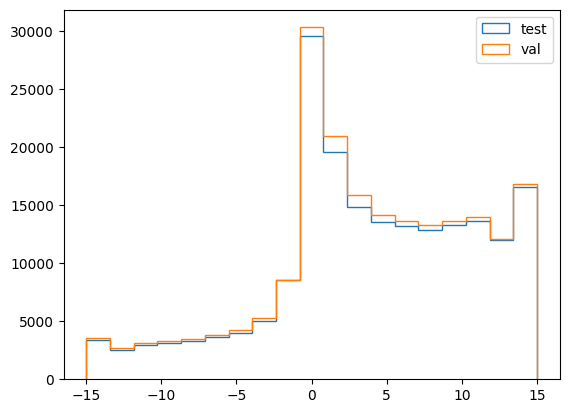

In [15]:
# Calculate returns
def calculate_returns(rewards, ids, gamma=0.95):
    def calc(g):
        returns = []
        for x in np.flip(g.values):
            if not returns: returns.append(x)
            else: returns.append(returns[-1] * gamma + x)
        return np.flip(np.array(returns))
    return rewards.groupby(ids).transform(calc)

returns_val = calculate_returns(rewards_val, val_df['id']).values
returns_test = calculate_returns(rewards_test, test_df['id']).values
print(pd.DataFrame({'id': val_df['id'], 'reward': rewards_val, 'return': returns_val}).iloc[20:40])
plt.figure()
plt.hist(returns_test, bins=np.linspace(-15, 15, 20), histtype='step', label='test')
plt.hist(returns_val, bins=np.linspace(-15, 15, 20), histtype='step', label='val')
plt.legend()
plt.show()

In [16]:
# Create dataset of weights and returns

def calculate_wis(action_df, weights_column='weights'):
    cum_weight_total = action_df[weights_column].sum()
    return np.sum(action_df['return'] * action_df[weights_column] / cum_weight_total)
    
def compute_ai_probs(recs, true_outputs, soften=0.05):
    ai_action_probs = (1 - soften) * (recs == true_outputs) + (soften / 11) * (recs != true_outputs)
    return ai_action_probs

wis_df = pd.DataFrame({
    'id': test_df['id'], 
    'timestep': (test_df['intime'] - test_df['intime'].groupby(test_df['id']).transform('min')) / (4 * 3600),
    'rec_prob': compute_ai_probs(recs_test, all_tx_outputs_test.values.flatten()),
    'true_prob': all_treatment_probs_test,
    'return': returns_test
})
wis_df['weights'] = (wis_df['rec_prob'] / wis_df['true_prob']).groupby(wis_df['id']).transform(lambda g: np.cumprod(g.values))
wis_df['clinician_weights'] = (wis_df['true_prob'] / wis_df['true_prob']).groupby(wis_df['id']).transform(lambda g: np.cumprod(g.values))

In [ ]:
bootstrap_iters = 10000
bootstrap_ais = []
bootstrap_clinicians = []

max_weight = np.quantile(wis_df['weights'], 0.999) 
exclude_flag = wis_df['weights'] >= max_weight
print(f"Weights for {exclude_flag.sum()} ({exclude_flag.mean():.2%}) of timesteps clipped to max weight {max_weight}")
wis_df_cleaned = wis_df.assign(weights=np.clip(wis_df['weights'], None, max_weight))

ai_policy_wis = calculate_wis(wis_df_cleaned)
clinician_policy_wis = calculate_wis(wis_df_cleaned, weights_column='clinician_weights')

id_indexes = {id: wis_df_cleaned.index[wis_df_cleaned['id'] == id].values for id in wis_df_cleaned['id'].unique()}

np.random.seed(1234)
for _ in tqdm.tqdm(range(bootstrap_iters)):
    sampled_ids = np.random.choice(wis_df_cleaned['id'].unique(), size=len(wis_df_cleaned['id'].unique()), replace=True)
    indexes = np.concatenate([id_indexes[id] for id in sampled_ids])
    bootstrapped_df = wis_df_cleaned.iloc[indexes]
    ai_bst = calculate_wis(bootstrapped_df)
    clinician_bst = calculate_wis(bootstrapped_df, weights_column='clinician_weights')
    bootstrap_ais.append(ai_bst)
    bootstrap_clinicians.append(clinician_bst)
    
bootstrap_ais = np.array(bootstrap_ais)
bootstrap_clinicians = np.array(bootstrap_clinicians)

# compute p value - https://stats.stackexchange.com/a/28725
b = bootstrap_ais - bootstrap_clinicians
b_under_h0 = b - b.mean()
p_value = (1 + (np.abs(b_under_h0) > (ai_policy_wis - clinician_policy_wis)).sum()) / (1 + len(b_under_h0))
print(ai_policy_wis - clinician_policy_wis, np.quantile(bootstrap_ais - bootstrap_clinicians, [0.025, 0.975]), p_value)

Weights for 376 (0.19%) of timesteps clipped to max weight 2867534.661838377


100%|██████████| 10000/10000 [01:35<00:00, 104.77it/s]

2.970354835187782 [1.22309659 4.61560139] 0.0028997100289971


In [17]:
wis_results = [{
    "cohort": "mimic",
    "subgroup": "all",
    "ai_estimate": ai_bst,
    "clinician_estimate": clinician_bst,
    "trial": i
} for i, (ai_bst, clinician_bst) in enumerate(zip(bootstrap_ais, bootstrap_clinicians))]
wis_means = [{
    "cohort": "mimic",
    "subgroup": "all",
    "ai_estimate": ai_policy_wis,
    "clinician_estimate": clinician_policy_wis
}]

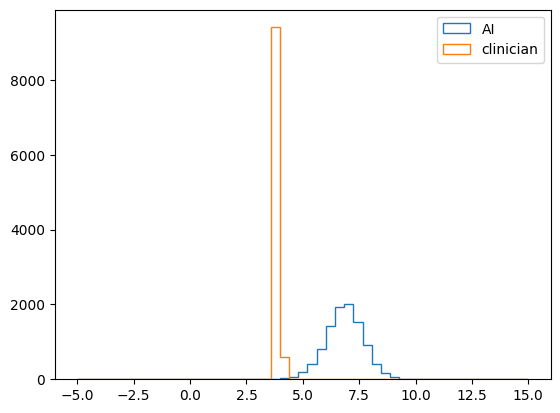

In [18]:
plt.hist(bootstrap_ais, bins=np.linspace(-5, 15, 50), histtype='step', label='AI')
plt.hist(bootstrap_clinicians, bins=np.linspace(-5, 15, 50), histtype='step', label='clinician')
plt.legend()
plt.show()

# Complexity Metrics

1. Number of abnormal lab categories >= 5
2. Unusualness according to model (distance greater than 0.75 quantile)
   - Note: the original code selected by the inverse (distance less than 0.25 quantile) due to an error, so the list of cases from which the vignettes were selected was not quite aligned with our definition of complexity. However, using the correct unusualness metric also includes all of the vignette patients.
3. Spread in plausible decisions >= 3 (also check number of plausible decisions)

In [17]:
RANGES_BY_SYSTEM = {
    "Cardiac": {
        "Lactic Acid": { "min": 0.5, "max": 1.6 },
        "Troponin": { "max": 1 }, # not sure what these units are
    },
    "Coags": {
        "PTT": { "min": 60, "max": 70 },
        "PT": { "min": 11, "max": 13.5 },
        "INR": { "min": 0.8, "max": 1.1 },
    },
    "ABGs": {
        "Arterial pH": { "min": 7.35, "max": 7.45 },
        "Arterial BE": { "min": -4, "max": 2 },
        "PaO2": { "min": 75, "max": 100 },
        "PaCO2": { "min": 35, "max": 45 },
        "Bicarbonate": { "min": 20, "max": 32 },
    },
    "CBC": {
        "WBC Count": { "min": 4.5, "max": 11 },
        "Hemoglobin": { "male": { "min": 14.0, "max": 17.5 },
                        "female": { "min": 12.3, "max": 15.3 }},
        "Hematocrit": { "male": { "min": 41, "max": 50 },
                        "female": { "min": 36, "max": 48 }},
        "Platelet Count": { "min": 130, "max": 400 },
    },
    "Liver": {
        "AST": { "female": { "min": 9, "max": 25 }, "male": { "min": 10, "max": 40 } },
        "ALT": { "female": { "min": 7, "max": 30 }, "male": { "min": 10, "max": 55 } },
        "Total Bili": { "min": -1, "max": 5 },
        "Direct Bili": { "min": -1, "max": 2 },
    },
    "Chemistries": {
        "Potassium": { "min": 3.4, "max": 5 },
        "Sodium": { "min": 135, "max": 145 },
        "Chloride": { "min": 95, "max": 108 },
        "Glucose": { "min": 110, "max": 180 },
        "Ionized Ca": { "min": 1.1, "max": 1.4 },
    },
    "Renal": {
        "BUN": { "min": 8, "max": 25 },
        "Creatinine": {
            "female": { "min": 0.6, "max": 1.8 },
            "male": { "min": 0.8, "max": 2.4 },
          },
    },
    "Neuro": {
        "GCS Eye Opening": { "min": 3, "max": 6 },
        "GCS Motor Response": { "min": 3, "max": 7 },
        "GCS Verbal Response": { "min": 3, "max": 6 },
        "RASS": { "min": -3, "max": 2 }
    }
}

def _assign_bin_values(col_data, bin_spec):
    lower = bin_spec.get("min", np.quantile(col_data, 0.25))
    upper = bin_spec.get("max", np.quantile(col_data, 0.75))
    assert lower < upper, f"{bin_spec}"
    return np.digitize(col_data, [lower, upper]) != 1

EXTREME_VALUE_BIN_NAMES = {"normal": 0, "abnormal": 1}
def extreme_value_binning(col_name, norm_range, col_data, gender_data):
    if "female" in norm_range:
        return np.where(gender_data, 
                        _assign_bin_values(col_data, norm_range["female"]),
                        _assign_bin_values(col_data, norm_range["male"])), EXTREME_VALUE_BIN_NAMES
    return _assign_bin_values(col_data, norm_range), EXTREME_VALUE_BIN_NAMES

def get_abnormal_flags(states):
    abnormal_flags = []
    abnormal_flags_system = {}
    for system, system_ranges in RANGES_BY_SYSTEM.items():
        system_flags = np.vstack([
            np.logical_and(extreme_value_binning(lab_name, range_info, states[lab_name], states['gender_female'])[0],
                           states[f'{lab_name} Present'])
            for lab_name, range_info in system_ranges.items()
        ]).T
        # for lab_name, range_info in system_ranges.items():
        #     print(lab_name, range_info, states[states['id'] == 32581623][lab_name].iloc[4], system_flags[states['id'] == 32581623][4])
        abnormal_flags.append(pd.DataFrame(system_flags, columns=list(system_ranges.keys())))
        abnormal_flags_system[system] = system_flags.any(axis=1)
    abnormal_flags = pd.concat(abnormal_flags, axis=1)
    abnormal_flags_system = pd.DataFrame(abnormal_flags_system)
    abnormal_flags['id'] = states['id']
    abnormal_flags['intime'] = states['intime']
    abnormal_flags_system['id'] = states['id']
    abnormal_flags_system['intime'] = states['intime']
    return abnormal_flags, abnormal_flags_system

abnormal_flags_val = get_abnormal_flags(pd.read_csv(os.path.join(data_dir, "model_features", "inputs_val.csv"), index_col=0)[val_mask].reset_index(drop=True))[1]
abnormal_flags_test = get_abnormal_flags(pd.read_csv(os.path.join(data_dir, "model_features", "inputs_test.csv"), index_col=0)[test_mask].reset_index(drop=True))[1]
print(abnormal_flags_val.mean(axis=0))

Cardiac        9.358074e-02
Coags          1.866194e-01
ABGs           2.541485e-01
CBC            2.774353e-01
Liver          6.216702e-02
Chemistries    3.982356e-01
Renal          2.134053e-01
Neuro          4.627091e-01
id             3.498431e+07
intime         5.801718e+09
dtype: float64


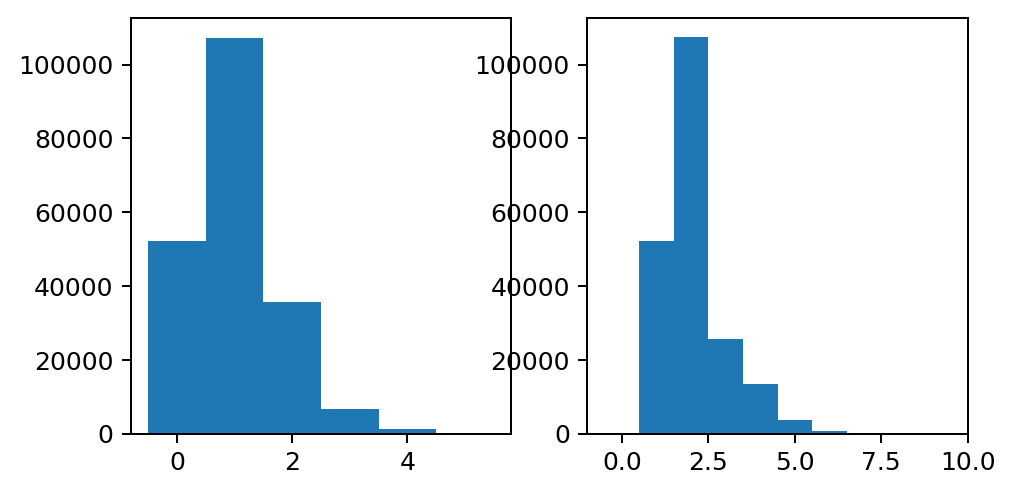

In [18]:
# Calculate the max spread in the decisions that are present
def max_spread(row):
    fluid_decs = (((row[row > 0].index // 3) + 1) % 4).values # adjust so that diuretics are first
    vaso_decs = (row[row > 0].index % 3).values
    if len(fluid_decs) == 0: return float('nan')
    diffs = np.abs(fluid_decs[:,None] - fluid_decs[None,:]) + np.abs(vaso_decs[:,None] - vaso_decs[None,:])
    return diffs.max()

plan_spread_val = plans_val.apply(max_spread, axis=1)
plan_spread_test = plans_test.apply(max_spread, axis=1)
plan_count_val = plans_val.sum(axis=1)
plan_count_test = plans_test.sum(axis=1)

plt.figure(figsize=(6, 3), dpi=180)
plt.subplot(121)
plt.hist(plan_spread_val, bins=np.arange(-0.5, 6.5))
plt.subplot(122)
plt.hist(plan_count_val, bins=np.arange(-0.5, 10.5))
plt.show()

In [19]:
# Compile all complexity metrics - define by whether they are met in at least
# 20% of trajectories

complex_val = val_df[['id', 'intime']].reset_index(drop=True).assign(
    high_spread=plan_spread_val.groupby(val_df['id']).transform(lambda g: (g >= 2).sum() >= len(g) * 0.2),
    many_options=plan_count_val.groupby(val_df['id']).transform(lambda g: (g >= 4).sum() >= len(g) * 0.2), # plan_count_val >= 5,
    abnormal=abnormal_flags_val.drop(columns=['id', 'intime']).sum(axis=1).groupby(val_df['id']).transform(lambda g: (g >= 5).sum() >= len(g) * 0.2), #  >= 6,
    severe=pd.Series(severity_scores_val).groupby(val_df['id']).transform(lambda g: (g >= 10).sum() >= len(g) * 0.2)
)
complex_test = test_df[['id', 'intime']].reset_index(drop=True).assign(
    high_spread=plan_spread_test.groupby(test_df['id']).transform(lambda g: (g >= 2).sum() >= len(g) * 0.2),
    many_options=plan_count_test.groupby(test_df['id']).transform(lambda g: (g >= 4).sum() >= len(g) * 0.2), # plan_count_val >= 5,
    abnormal=abnormal_flags_test.drop(columns=['id', 'intime']).sum(axis=1).groupby(test_df['id']).transform(lambda g: (g >= 5).sum() >= len(g) * 0.2), #  >= 6,
    severe=pd.Series(severity_scores_test).groupby(test_df['id']).transform(lambda g: (g >= 10).sum() >= len(g) * 0.2)
)


In [20]:
print("any:", complex_test[['high_spread', 'many_options', 'abnormal', 'severe']].any(axis=1).mean())
print("all:", complex_test[['high_spread', 'many_options', 'abnormal', 'severe']].all(axis=1).mean())
print("plan-based:", complex_test[['high_spread', 'many_options']].all(axis=1).mean())

print(complex_test[['high_spread', 'many_options', 'abnormal']].mean(axis=0))
print(complex_test[complex_test[['high_spread', 'many_options', 'abnormal']].any(axis=1)]['id'].nunique(), complex_test['id'].nunique())

print("total:", len(complex_test), len(complex_test['id'].unique()), test_morta.groupby(complex_test['id']).max().mean())

any: 0.5554084178664922
all: 0.05629806119109947
plan-based: 0.15251758835078533
high_spread     0.394276
many_options    0.152518
abnormal        0.214205
dtype: float64
3223 6928
total: 195584 6928 0.16729214780600463


Weights for 197 (0.10%) of timesteps clipped to max weights 1338.033256474472 and 17319005.054810155


100%|██████████| 10000/10000 [02:14<00:00, 74.46it/s]


In subgroup: -1.4320607207278746 [-4.20711567  1.82540954] 0.3584641535846415
DiD: high_spread -4.834489651805193 [-8.11380455 -1.28779187] 0.0064993500649935


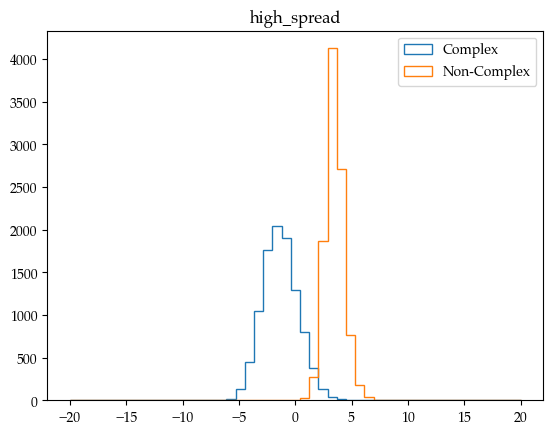

Weights for 196 (0.10%) of timesteps clipped to max weights 524.3507346376308 and 4912497.119069979


100%|██████████| 10000/10000 [02:19<00:00, 71.70it/s]

In subgroup: -1.7025589550855016 [-4.96805402  3.72218025] 0.4567543245675432
DiD: many_options -4.784385265754828 [-8.56072801  0.81826315] 0.0448955104489551


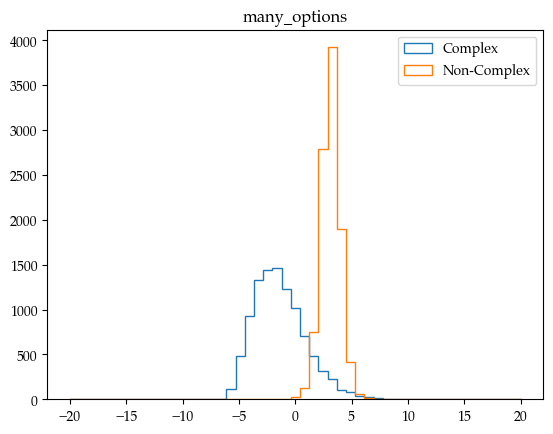

Weights for 196 (0.10%) of timesteps clipped to max weights 8493.612810482064 and 6490527.9536959855


100%|██████████| 10000/10000 [02:20<00:00, 71.39it/s]


In subgroup: -2.975346118344213 [-6.24037212  1.37681716] 0.10848915108489152
DiD: abnormal -6.003840507868718 [-9.73180296 -1.41824951] 0.0081991800819918


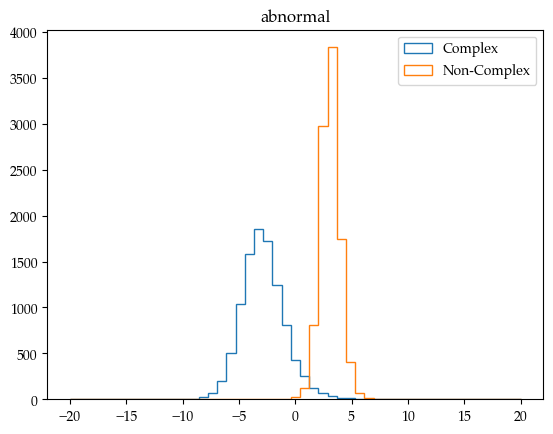

Weights for 197 (0.10%) of timesteps clipped to max weights 15826.040606420243 and 16090088.586168949


100%|██████████| 10000/10000 [02:17<00:00, 72.56it/s]

In subgroup: 2.3735040279913964 [-1.28182052  5.37315289] 0.16478352164783522
DiD: severe -0.1393024167106871 [-4.25671282  3.19237266] 0.9402059794020597


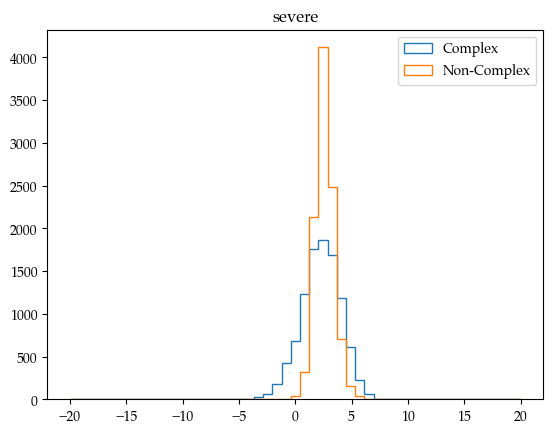

In [43]:
subgroup_p_values = []
final_p_values = []
for flag in ['high_spread', 'many_options', 'abnormal', 'severe']:
    # Cut off by quantile separately for complex and simple cases since the WIS
    # will be performed separately
    final_cutoffs = {True: 0.999, False: 0.999}

    bootstrap_iters = 10000

    bootstrap_ai_complex = []
    bootstrap_clinicians_complex = []
    bootstrap_ai_noncomplex = []
    bootstrap_clinicians_noncomplex = []

    complex_df = wis_df.copy().assign(complex_flag=complex_test[flag], simple_flag=~complex_test[flag])
    max_weight_simple = np.quantile(complex_df[complex_df['simple_flag']]['weights'], final_cutoffs.get(False, 0.9))
    max_weight = np.quantile(complex_df[complex_df['complex_flag']]['weights'], final_cutoffs.get(True, 0.9))
    exclude_flag = ((complex_df['complex_flag'] & 
                    (complex_df['weights'] >= max_weight)) | 
                    (complex_df['simple_flag'] & 
                    (complex_df['weights'] >= max_weight_simple)))
    print(f"Weights for {exclude_flag.sum()} ({exclude_flag.mean():.2%}) of timesteps clipped to max weights {max_weight} and {max_weight_simple}")
    complex_df = complex_df.assign(weights=np.clip(complex_df['weights'], None, 
                                                   np.where(complex_df['complex_flag'], max_weight, max_weight_simple))) #  # complex_df[~exclude_flag].reset_index(drop=True)

    ai_policy_wis_c = calculate_wis(complex_df[complex_df['complex_flag']])
    clinician_policy_wis_c = calculate_wis(complex_df[complex_df['complex_flag']], weights_column='clinician_weights')
    ai_policy_wis_nc = calculate_wis(complex_df[complex_df['simple_flag']])
    clinician_policy_wis_nc = calculate_wis(complex_df[complex_df['simple_flag']], weights_column='clinician_weights')
    
    id_indexes = {id: complex_df.index[complex_df['id'] == id].values for id in complex_df['id'].unique()}
    
    np.random.seed(1234)
    for _ in tqdm.tqdm(range(bootstrap_iters)):
        sampled_ids = np.random.choice(complex_df['id'].unique(), size=len(complex_df['id'].unique()), replace=True)
        indexes = np.concatenate([id_indexes[id] for id in sampled_ids])
        bootstrapped_df = complex_df.iloc[indexes]
        ai_bst_c = calculate_wis(bootstrapped_df[bootstrapped_df['complex_flag']])
        clinician_bst_c = calculate_wis(bootstrapped_df[bootstrapped_df['complex_flag']], weights_column='clinician_weights')
        ai_bst_nc = calculate_wis(bootstrapped_df[bootstrapped_df['simple_flag']])
        clinician_bst_nc = calculate_wis(bootstrapped_df[bootstrapped_df['simple_flag']], weights_column='clinician_weights')
        bootstrap_ai_complex.append(ai_bst_c)
        bootstrap_clinicians_complex.append(clinician_bst_c)
        bootstrap_ai_noncomplex.append(ai_bst_nc)
        bootstrap_clinicians_noncomplex.append(clinician_bst_nc)
        
    bootstrap_ai_complex = np.array(bootstrap_ai_complex)
    bootstrap_clinicians_complex = np.array(bootstrap_clinicians_complex)
    bootstrap_ai_noncomplex = np.array(bootstrap_ai_noncomplex)
    bootstrap_clinicians_noncomplex = np.array(bootstrap_clinicians_noncomplex)

    b = (bootstrap_ai_complex - bootstrap_clinicians_complex)
    b_under_h0 = b - b.mean()
    estimate_0 = (ai_policy_wis_c - clinician_policy_wis_c)
    p_value_subgroup = (1 + (np.abs(b_under_h0) > np.abs(estimate_0)).sum()) / (1 + len(b_under_h0))
    print("In subgroup:", estimate_0, np.quantile(bootstrap_ai_complex - bootstrap_clinicians_complex, [0.025, 0.975]), p_value_subgroup)
    
    b = (bootstrap_ai_complex - bootstrap_clinicians_complex) - (bootstrap_ai_noncomplex - bootstrap_clinicians_noncomplex)
    b_under_h0 = b - b.mean()
    estimate_0 = (ai_policy_wis_c - clinician_policy_wis_c) - (ai_policy_wis_nc - clinician_policy_wis_nc)
    p_value = (1 + (np.abs(b_under_h0) > np.abs(estimate_0)).sum()) / (1 + len(b_under_h0))
    print("DiD:", flag, estimate_0, 
          np.quantile((bootstrap_ai_complex - bootstrap_clinicians_complex) - (bootstrap_ai_noncomplex - bootstrap_clinicians_noncomplex), [0.025, 0.975]),
          p_value)
    subgroup_p_values.append({
        "cohort": "mimic",
        "subgroup": flag,
        "p_value": p_value_subgroup
    })
    final_p_values.append({
        "cohort": "mimic",
        "subgroup": flag,
        "p_value": p_value
    })

    wis_results += [{
        "cohort": "mimic",
        "matches": True,
        "subgroup": flag,
        "ai_estimate": ai_bst,
        "clinician_estimate": clinician_bst,
        "trial": i
    } for i, (ai_bst, clinician_bst) in enumerate(zip(bootstrap_ai_complex, bootstrap_clinicians_complex))]
    wis_results += [{
        "cohort": "mimic",
        "matches": False,
        "subgroup": flag,
        "ai_estimate": ai_bst,
        "clinician_estimate": clinician_bst,
        "trial": i
    } for i, (ai_bst, clinician_bst) in enumerate(zip(bootstrap_ai_noncomplex, bootstrap_clinicians_noncomplex))]
    wis_means.append({
        "cohort": "mimic",
        "matches": True,
        "subgroup": flag,
        "ai_estimate": ai_policy_wis_c,
        "clinician_estimate": clinician_policy_wis_c
    })
    wis_means.append({
        "cohort": "mimic",
        "matches": False,
        "subgroup": flag,
        "ai_estimate": ai_policy_wis_nc,
        "clinician_estimate": clinician_policy_wis_nc
    })
    plt.hist(bootstrap_ai_complex - bootstrap_clinicians_complex, bins=np.linspace(-20, 20, 50), histtype='step', label='Complex')
    plt.hist(bootstrap_ai_noncomplex - bootstrap_clinicians_noncomplex, bins=np.linspace(-20, 20, 50), histtype='step', label='Non-Complex')
    plt.title(flag)
    plt.legend()
    plt.show()


In [27]:
pd.DataFrame(wis_results).to_csv("mimic_wis_results_all_adaptive_truncation.csv", index=False)
pd.DataFrame(wis_means).to_csv("mimic_wis_means_all_adaptive_truncation.csv", index=False)

In [42]:
# Perform multiple hypothesis correction
from statsmodels.stats.multitest import multipletests

corr_p_values = multipletests([p["p_value"] for p in subgroup_p_values], method='holm')[1]
print("Corrected p-values for AI vs. clinician:", list(zip([p["subgroup"] for p in subgroup_p_values], corr_p_values)))

corr_p_values = multipletests([p["p_value"] for p in final_p_values], method='holm')[1]
print("Corrected p-values for difference in differences:", list(zip([p["subgroup"] for p in final_p_values], corr_p_values)))

Corrected p-values for AI vs. clinician: [('high_spread', 0.716928307169283), ('many_options', 0.716928307169283), ('abnormal', 0.43395660433956607), ('severe', 0.49435056494350565)]
Corrected p-values for difference in differences: [('high_spread', 0.025997400259974), ('many_options', 0.0897910208979102), ('abnormal', 0.025997400259974), ('severe', 0.9402059794020597)]


In [32]:
# How are the decisions themselves different within each category?

def make_fluid_comparisons(true, pred):
    true = (true + 1) % 4
    pred = (pred + 1) % 4
    return pd.Series(np.where(true > pred, 'More Fluid', np.where(true < pred, 'Less Fluid', 'Same')))

def make_vaso_comparisons(true, pred):
    return pd.Series(np.where(true > pred, 'More VP', np.where(true < pred, 'Less VP', 'Same')))

fluid_comparisons_base = make_fluid_comparisons(
    treatments_test['fluid'].values,
    recs_test.values // 3)
vaso_comparisons_base = make_vaso_comparisons(
    treatments_test['vaso'].values,
    recs_test.values % 3)

fluid_comparisons_base.value_counts(), vaso_comparisons_base.value_counts()

(Same          132263
 More Fluid     32903
 Less Fluid     30418
 Name: count, dtype: int64,
 Same       176931
 More VP     15562
 Less VP      3091
 Name: count, dtype: int64)

In [33]:
print((treatments_test['fluid'].values == (recs_test.values // 3)).mean(), 
          (treatments_test['vaso'].values == (recs_test.values % 3)).mean())
for flag in ['abnormal', 'high_spread', 'many_options', 'severe']:
    print(flag)
    fluid_comparisons_comp = make_fluid_comparisons(
        treatments_test['fluid'].values[complex_test[flag]],
        recs_test.values[complex_test[flag]] // 3)
    vaso_comparisons_comp = make_vaso_comparisons(
        treatments_test['vaso'].values[complex_test[flag]],
        recs_test.values[complex_test[flag]] % 3)
    fluid_summary = pd.concat([
        fluid_comparisons_base.value_counts(normalize=True).rename('base'),
        fluid_comparisons_comp.value_counts(normalize=True).rename('comparison')
    ], axis=1)
    vaso_summary = pd.concat([
        vaso_comparisons_base.value_counts(normalize=True).rename('base'),
        vaso_comparisons_comp.value_counts(normalize=True).rename('comparison')
    ], axis=1)
    fluid_summary['proportion'] = fluid_summary['comparison'] / fluid_summary['base']
    vaso_summary['proportion'] = vaso_summary['comparison'] / vaso_summary['base']
    print((treatments_test['fluid'].values[complex_test[flag]] == (recs_test.values[complex_test[flag]] // 3)).mean(), 
          (treatments_test['vaso'].values[complex_test[flag]] == (recs_test.values[complex_test[flag]] % 3)).mean())
    print(fluid_summary)
    print(vaso_summary)
    print("")

0.6762465232329843 0.9046292130235603
abnormal
0.6395035207065283 0.8406015037593985
                base  comparison  proportion
Same        0.676247    0.639504    0.945666
More Fluid  0.168230    0.215300    1.279800
Less Fluid  0.155524    0.145196    0.933595
             base  comparison  proportion
Same     0.904629    0.840602    0.929222
More VP  0.079567    0.129395    1.626242
Less VP  0.015804    0.030004    1.898486

high_spread
0.6104728064942812 0.8178151827164977
                base  comparison  proportion
Same        0.676247    0.610473    0.902737
More Fluid  0.168230    0.230010    1.367240
Less Fluid  0.155524    0.159517    1.025675
             base  comparison  proportion
Same     0.904629    0.817815    0.904034
More VP  0.079567    0.151685    1.906379
Less VP  0.015804    0.030500    1.929916

many_options
0.5862889708347301 0.7461951055983909
                base  comparison  proportion
Same        0.676247    0.586289    0.866975
More Fluid  0.168230    0.

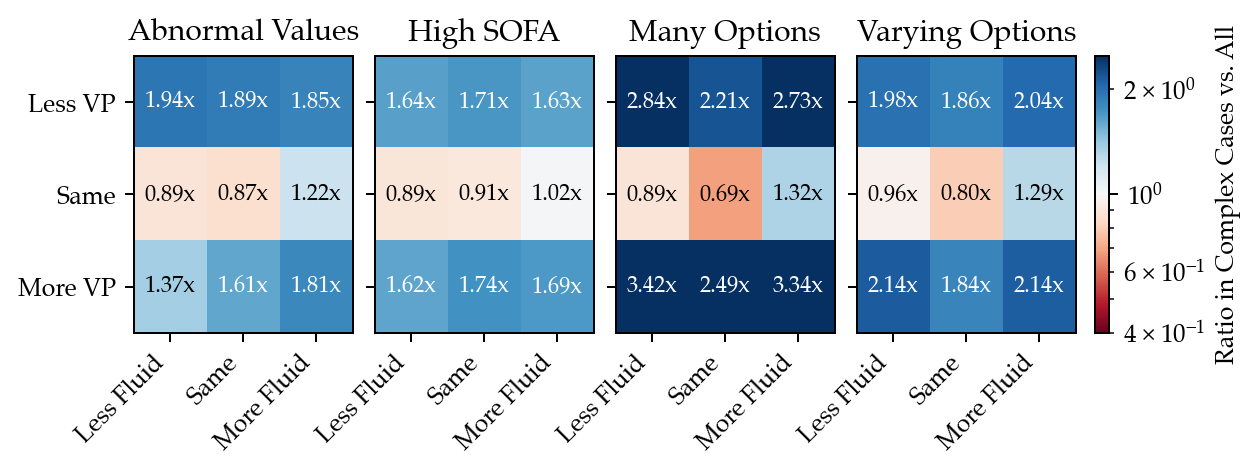

In [34]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Palatino', 'Palatino Linotype', 'Times New Roman']
plt.rcParams['mathtext.fontset'] = 'dejavuserif'

from matplotlib.colors import LogNorm
from matplotlib.ticker import FuncFormatter

fluid_order = ['Less Fluid', 'Same', 'More Fluid']
vaso_order = ['Less VP', 'Same', 'More VP']

def make_action_diff_series(true_fluid, pred_fluid, true_vaso, pred_vaso):
    fluid = pd.Series(np.select(
        [true_fluid > pred_fluid, true_fluid < pred_fluid],
        ['More Fluid', 'Less Fluid'],
        default='Same'
    ))
    vaso = pd.Series(np.select(
        [true_vaso > pred_vaso, true_vaso < pred_vaso],
        ['More VP', 'Less VP'],
        default='Same'
    ))
    return fluid, vaso

def ratio_heatmap(flag):
    flag_mask = complex_test[flag].values

    fluid_comp, vaso_comp = make_action_diff_series(
        (treatments_test['fluid'].values[flag_mask] + 1) % 4,
        ((recs_test.values[flag_mask] // 3) + 1) % 4,
        treatments_test['vaso'].values[flag_mask],
        (recs_test.values[flag_mask] % 3),
    )

    fluid_base, vaso_base = make_action_diff_series(
        (treatments_test['fluid'].values + 1) % 4,
        ((recs_test.values // 3) + 1) % 4,
        treatments_test['vaso'].values,
        (recs_test.values % 3),
    )

    base_counts = pd.crosstab(vaso_base, fluid_base, dropna=False).reindex(
        index=vaso_order, columns=fluid_order, fill_value=0
    )
    comp_counts = pd.crosstab(vaso_comp, fluid_comp, dropna=False).reindex(
        index=vaso_order, columns=fluid_order, fill_value=0
    )

    base_prop = base_counts / base_counts.to_numpy().sum()
    comp_prop = comp_counts / comp_counts.to_numpy().sum()

    ratio = comp_prop.div(base_prop.replace(0, np.nan)).fillna(0.0)
    return ratio

def format_ratio_value(v):
    if np.isnan(v):
        return ''
    return f'{v:.2f}x'

fig, axes = plt.subplots(1, 4, figsize=(7, 2), dpi=180, gridspec_kw={'hspace': 0.2, 'wspace': 0.1})
metrics = ['abnormal', 'severe', 'many_options', 'high_spread']
titles = ['Abnormal Values', 'High SOFA', 'Many Options', 'Varying Options']

all_mats = [ratio_heatmap(flag) for flag in metrics]

for i, (ax, flag, title, mat) in enumerate(zip(axes.ravel(), metrics, titles, all_mats)):
    im = ax.imshow(mat.to_numpy(), cmap='RdBu', norm=LogNorm(vmin=1 / 2.5, vmax=2.5), aspect='auto')
    ax.set_title(title)
    ax.set_xticks(range(len(fluid_order)))
    ax.set_xticklabels(fluid_order, rotation=45, ha='right')
    ax.set_yticks(range(len(vaso_order)))
    if i != 0:
        ax.set_yticklabels([])
    else:
        ax.set_yticklabels(vaso_order)

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat.iloc[i, j]
            ax.text(j, i, format_ratio_value(val), ha='center', va='center',
                    color='black' if np.abs(np.log10(val)) <= 0.2 else 'white', fontsize=9)

cbar = fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.015, pad=0.02)
cbar.set_label('Ratio in Complex Cases vs. All')

# plt.tight_layout()
plt.savefig('treatment_variation_complex_whole_trajectory.png', dpi=300, bbox_inches='tight')
plt.show()

# Plotting

In [35]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Palatino', 'Palatino Linotype', 'Times New Roman']
plt.rcParams['mathtext.fontset'] = 'dejavuserif'

wis_df = pd.concat([
    pd.read_csv("mimic_wis_results_all_adaptive_truncation.csv"),
])
wis_means_df = pd.concat([
    pd.read_csv("mimic_wis_means_all_adaptive_truncation.csv"),
])
wis_means_df

,cohort,subgroup,ai_estimate,clinician_estimate,matches
0,mimic,all,6.826901,3.856546,NaN
1,mimic,high_spread,1.199643,2.631704,True
2,mimic,high_spread,8.056245,4.653816,False
3,mimic,many_options,0.125911,1.828470,True
4,mimic,many_options,7.303356,4.221530,False
5,mimic,abnormal,-1.575360,1.399987,True
6,mimic,abnormal,7.554689,4.526195,False
7,mimic,severe,3.516159,1.142655,True
8,mimic,severe,8.065842,5.553036,False


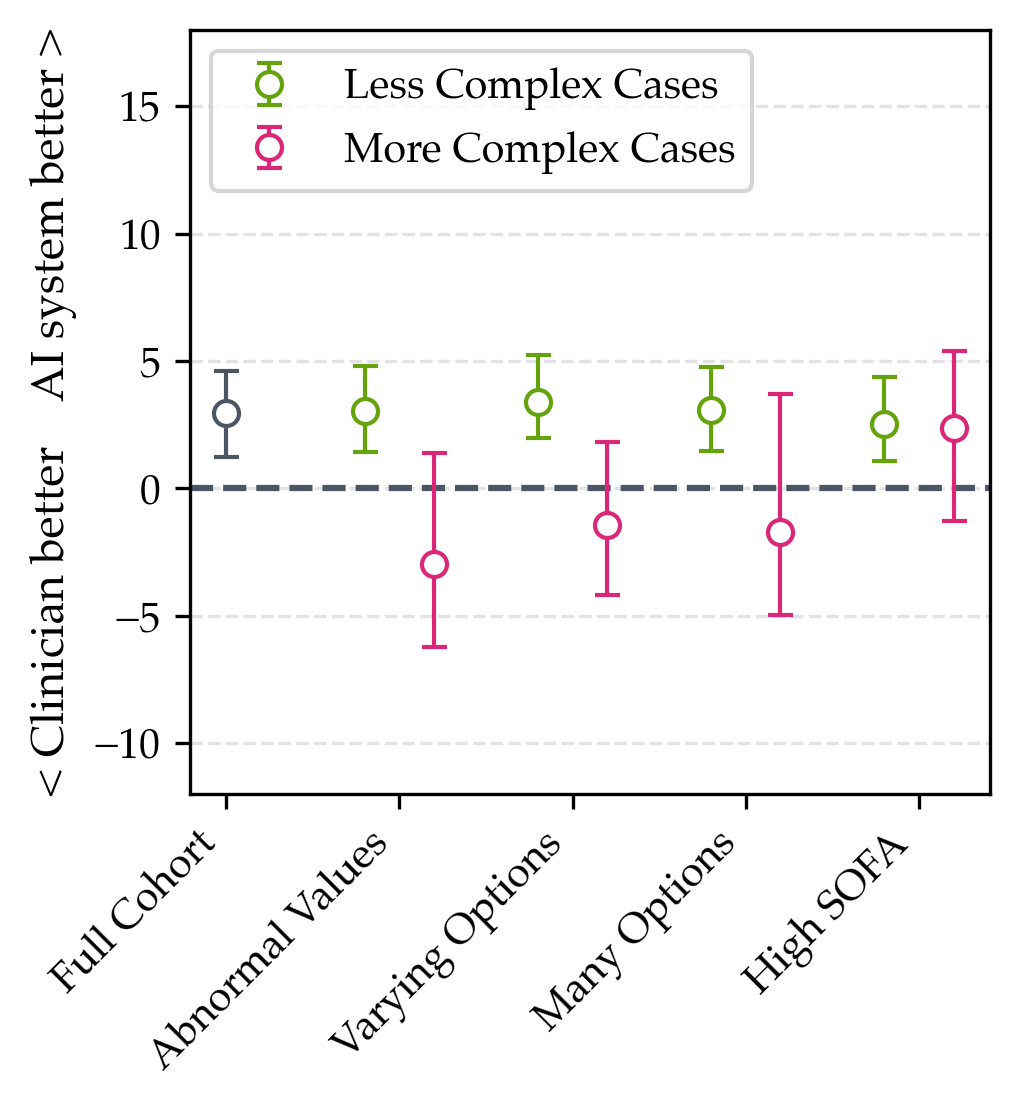

In [ ]:
def plot_wis_comparison(wis_df, wis_means_df):
    import seaborn as sns
    
    # Calculate differences
    wis_df['difference'] = wis_df['ai_estimate'] - wis_df['clinician_estimate']
    wis_means_df['difference'] = wis_means_df['ai_estimate'] - wis_means_df['clinician_estimate']
    
    # Create figure with single plot
    fig, ax = plt.subplots(figsize=(3.5, 4), dpi=300)
    
    subgroup_order = ['all', 'abnormal', 'high_spread', 'many_options', 'severe']
    subgroup_labels = {
        'all': 'Full Cohort',
        'high_spread': 'Varying Options',
        'many_options': 'Many Options',
        'abnormal': 'Abnormal Values',
        'severe': 'High SOFA'
    }
    
    cohort_colors = {True: '#db2777', False: '#65a30d'}
    cohort_offset = {False: -0.2, True: 0.2}
    
    y_positions = list(range(len(subgroup_order)))
    
    # Full cohort
    subgroup_data = wis_df[wis_df['subgroup'] == 'all']['difference']
    offset = 0.0
    i = 0
    
    # Create violin plot
    # parts = ax.violinplot(
    #     [subgroup_data.values],
    #     positions=[i + offset],
    #     vert=True,
    #     widths=0.3,
    #     showmeans=False,
    #     showmedians=False
    # )
    
    # Style the violin plot
    # for pc in parts['bodies']:
    #     pc.set_facecolor('#d5d5d5')
    #     pc.set_alpha(0.8)
    # for partname in ('cbars', 'cmins', 'cmaxes', 'cmedians'):
    #     if partname in parts:
    #         parts[partname].set_edgecolor('#4b5563')
    #         parts[partname].set_linewidth(1.5)
    
    # Add mean point
    mean_val = wis_means_df[wis_means_df['subgroup'] == 'all']['difference'].values[0]
    # ax.boxplot(wis_df[wis_df['subgroup'] == 'all']['difference'].values, 
    #            sym='',
    #            positions=[i + offset], widths=[0.25], boxprops={'color': '#4b5563'}, medianprops={'color': '#4b5563'})
    # ax.scatter([i + offset], [mean_val], color='#4b5563', s=32, zorder=3, marker='o', edgecolors='k', linewidth=0.5)
    ax.errorbar(
        x=[i + offset],
        y=[mean_val],
        yerr=np.array([(mean_val - np.quantile(subgroup_data.values, 0.025), np.quantile(subgroup_data.values, 0.975) - mean_val)]).T,
        markersize=6, zorder=3, marker='o', elinewidth=1,
        linestyle='none',
        capsize=3,
        ecolor='#4b5563',
        mfc='white',
        mec='#4b5563',
        mew=1
    )


    for matches in [False, True]:
        cohort_data = wis_df[wis_df['matches'] == matches]
        cohort_means = wis_means_df[wis_means_df['matches'] == matches]
        
        for i, subgroup in enumerate(subgroup_order[1:], 1):
            subgroup_data = cohort_data[cohort_data['subgroup'] == subgroup]['difference']
            offset = cohort_offset[matches]
            
            # Create violin plot
            # parts = ax.violinplot(
            #     [subgroup_data.values],
            #     positions=[i + offset],
            #     vert=True,
            #     widths=0.3,
            #     showmeans=False,
            #     showmedians=False,
            # )
            
            # # Style the violin plot
            # for pc in parts['bodies']:
            #     pc.set_facecolor('#d5d5d5')
            #     pc.set_alpha(0.8)
            # for partname in ('cbars', 'cmins', 'cmaxes', 'cmedians'):
            #     if partname in parts:
            #         parts[partname].set_edgecolor(cohort_colors[matches])
            #         parts[partname].set_linewidth(1.5)
            
            # Add mean point
            mean_val = cohort_means[cohort_means['subgroup'] == subgroup]['difference'].values[0]
            # ax.boxplot(subgroup_data.values, 
            #            sym='', 
            #            positions=[i + offset], 
            #            widths=[0.25],
            #            boxprops={'color': cohort_colors[matches], 'zorder': 5}, 
            #            medianprops={'color': cohort_colors[matches]},
            #            label=('More Complex Cases' if matches else 'Less Complex Cases') if i == 1 else None)
            # ax.scatter([i + offset], [mean_val], color=cohort_colors[matches], s=32, zorder=3, marker='o', edgecolors='k', linewidth=0.5, label=('More Complex Cases' if matches else 'Less Complex Cases') if i == 1 else None)
            ax.errorbar(
                x=[i + offset],
                y=[mean_val],
                yerr=np.array([(mean_val - np.quantile(subgroup_data.values, 0.025), np.quantile(subgroup_data.values, 0.975) - mean_val)]).T,
                markersize=6, zorder=3, marker='o', elinewidth=1,
                linestyle='none',
                capsize=3,
                ecolor=cohort_colors[matches],
                mfc='white',
                mec=cohort_colors[matches],
                mew=1,
                label=('More Complex Cases' if matches else 'Less Complex Cases') if i == 1 else None
            )
            
    # Formatting
    # ax.invert_yaxis()
    ax.set_xticks(y_positions)
    ax.set_xticklabels([subgroup_labels[sg] for sg in subgroup_order], ha='right', rotation=45)
    ax.axhline(0, color='#4b5563', linestyle='--', linewidth=1.5)
    ax.set_ylabel('< Clinician better    AI system better >', fontsize=11)
    ax.grid(visible=True, axis='y', which='major', color='#9ca3af', linestyle='--', alpha=0.3)
    ax.set_ylim(-12, 18)
    
    # Add legend
    # from matplotlib.patches import Patch
    # legend_elements = [Patch(facecolor=cohort_colors['mimic'], alpha=1, label='MIMIC'),
    #                    Patch(facecolor=cohort_colors['ucsf'], alpha=1, label='UCSF')]
    # ax.legend(handles=legend_elements, loc='upper right', frameon=True)
    ax.legend(loc='upper left')
    
    # Add shared x-axis label with directional text
    # fig.text(0.5, 0.02, '< Clinician Better     AI Better >', 
    #          ha='center', fontsize=11, style='italic')
    
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    return fig, ax

# Usage
fig, ax = plot_wis_comparison(wis_df, wis_means_df)
plt.savefig("wis_results.svg")
plt.show()

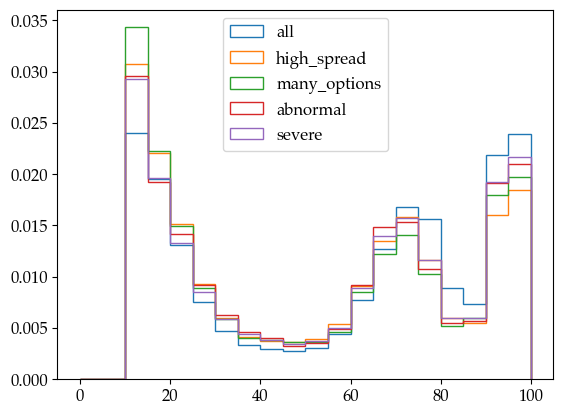

In [454]:
plt.hist(rec_sample_sizes_test, bins=np.linspace(0, 100, 21), density=True, histtype='step', label='all')
for c in ['high_spread', 'many_options', 'abnormal', 'severe']:
    plt.hist(rec_sample_sizes_test[complex_test[c]], bins=np.linspace(0, 100, 21), density=True, histtype='step', label=c)
plt.legend()
plt.show()

In [ ]:
import umap

# test_encoded = model_trainer.encode(model_trainer.test_dataset)
np.random.seed(1234)
sample_indexes = np.random.choice(len(test_encoded), size=20000)
encodings_mapped = umap.UMAP(n_neighbors=50, n_epochs=1000, verbose=True, metric='cosine').fit_transform(test_encoded[sample_indexes])
# encodings_pca = PCA().fit_transform(encodings)

/Users/vsivaram/miniconda3/envs/sepsis-ai/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


UMAP(angular_rp_forest=True, metric='cosine', n_epochs=1000, n_neighbors=50, verbose=True)
Thu Sep 10 11:29:53 2026 Construct fuzzy simplicial set
Thu Sep 10 11:29:53 2026 Finding Nearest Neighbors
Thu Sep 10 11:29:53 2026 Building RP forest with 12 trees
Thu Sep 10 11:29:54 2026 NN descent for 14 iterations
	 1  /  14
	 2  /  14
	 3  /  14
	Stopping threshold met -- exiting after 3 iterations
Thu Sep 10 11:30:00 2026 Finished Nearest Neighbor Search
Thu Sep 10 11:30:01 2026 Construct embedding


Epochs completed:   0%|            0/1000 [00:00]

	completed  0  /  1000 epochs
	completed  100  /  1000 epochs
	completed  200  /  1000 epochs
	completed  300  /  1000 epochs
	completed  400  /  1000 epochs
	completed  500  /  1000 epochs
	completed  600  /  1000 epochs
	completed  700  /  1000 epochs
	completed  800  /  1000 epochs
	completed  900  /  1000 epochs
Thu Sep 10 11:30:16 2026 Finished embedding


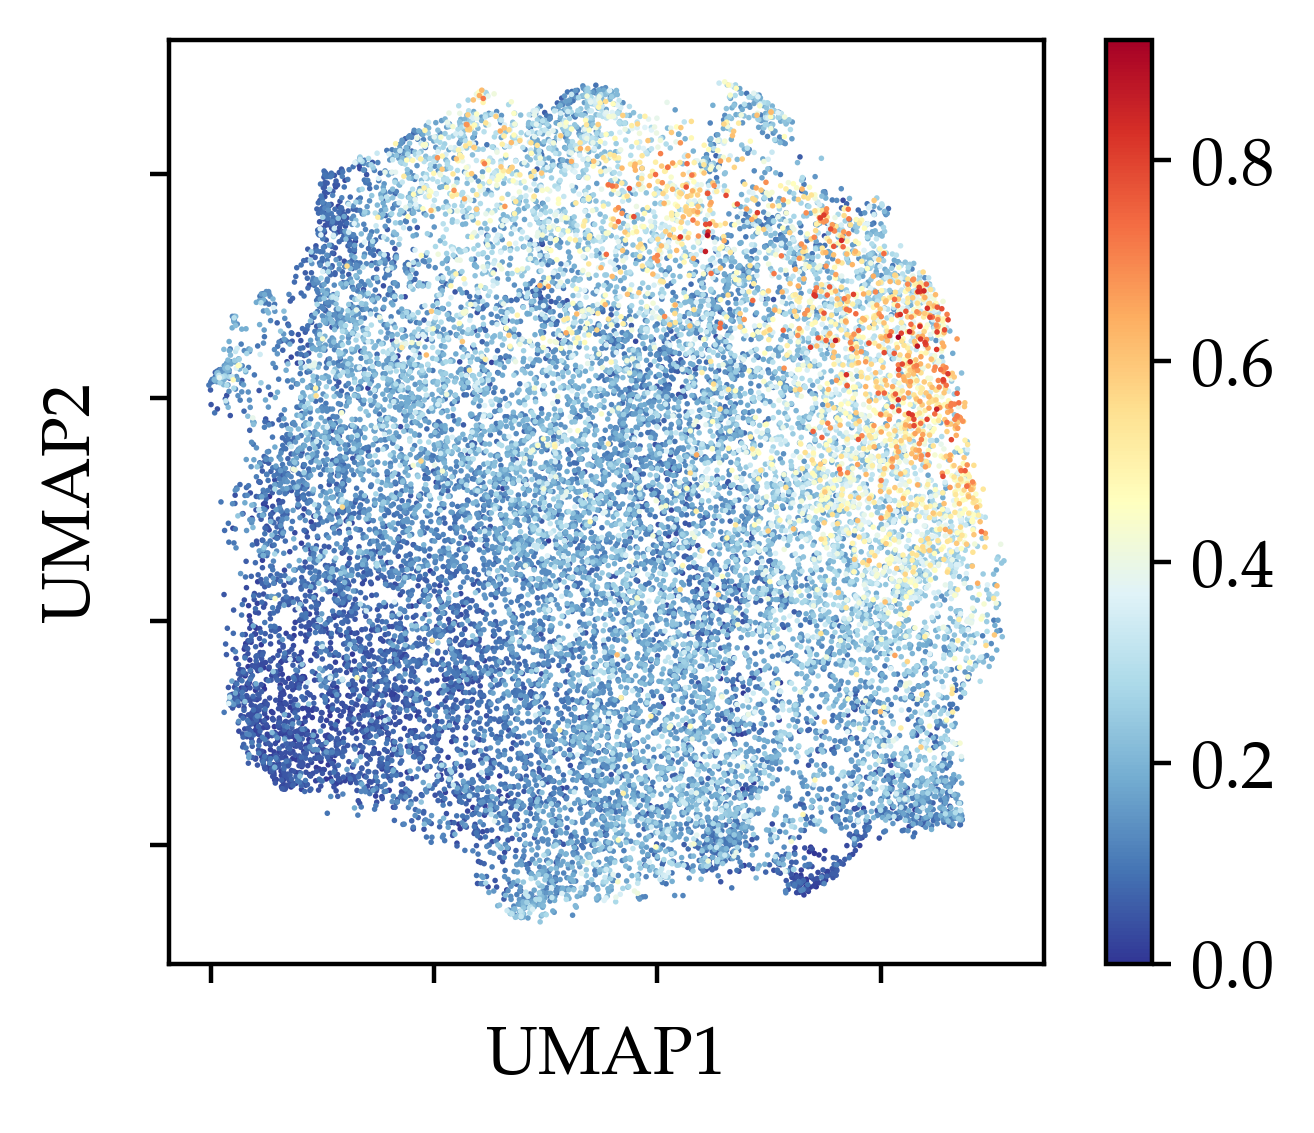

In [100]:
matplotlib.rc('font', size=12, family='Palatino')

train_outcome = pd.read_csv(os.path.join(data_dir, "outcomes", "morta", "train.csv"), index_col=0).iloc[:,-1].values[train_mask]
prob_comparisons = np.zeros(len(sample_indexes))
for i, idx in enumerate(sample_indexes):
    prob_comparisons[i] = train_outcome[test_neighb_train[idx]].mean()

plt.figure(figsize=(4, 3), dpi=400)
# plt.hexbin(encodings_mapped[:,0], encodings_mapped[:,1], gridsize=80, C=prob_comparisons, lw=0, cmap='RdYlBu_r', vmin=0)
render_order = np.argsort(prob_comparisons)
plt.scatter(encodings_mapped[:,0][render_order], encodings_mapped[:,1][render_order], c=prob_comparisons[render_order], s=1, lw=0, cmap='RdYlBu_r', vmin=0)
plt.gca().set_aspect(1.0)
plt.gca().set_xticklabels([])
plt.gca().set_yticklabels([])
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.colorbar()
plt.savefig(os.path.join(model_dir, "mortality_risk_test_set.svg"))
plt.show()

In [68]:
len(train_df) + len(val_df), len(train_df['id'].unique()) + len(val_df['id'].unique())

(594851, 21065)

100%|██████████| 195584/195584 [00:00<00:00, 480879.88it/s]


severe 0.6793269946103279
abnormal 0.7294233778836022
high_spread 0.7305801076269443
many_options 0.746137619200903


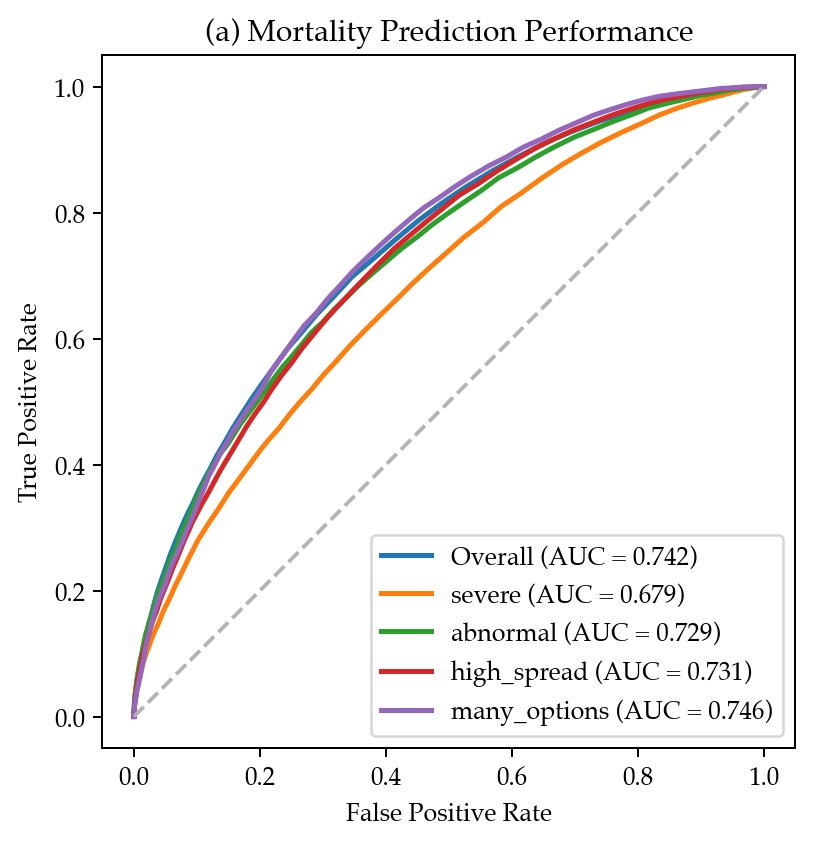

In [41]:
# Plot mortality prediction performance in each subgroup

from sklearn.metrics import roc_curve, roc_auc_score

train_outcome = pd.read_csv(os.path.join(data_dir, "outcomes", "morta", "train.csv"), index_col=0).iloc[:,-1].values[train_mask]
test_outcome = pd.read_csv(os.path.join(data_dir, "outcomes", "morta", "test.csv"), index_col=0).iloc[:,-1].values[test_mask]
prob_comparisons = np.zeros(len(test_df))
for idx in tqdm.tqdm(range(len(test_df))):
    prob_comparisons[idx] = train_outcome[test_neighb_train[idx]].mean()

plt.figure(figsize=(7.5, 5), dpi=180)

fpr, tpr, thresholds = roc_curve(test_outcome, prob_comparisons)
auroc = roc_auc_score(test_outcome, prob_comparisons)
plt.plot(fpr, tpr, lw=2, label=f'Overall (AUC = {auroc:.3f})')

for complexity_measure in ['severe', 'abnormal', 'high_spread', 'many_options']:
    fpr, tpr, thresholds = roc_curve(test_outcome[complex_test[complexity_measure]], prob_comparisons[complex_test[complexity_measure]])
    auroc = roc_auc_score(test_outcome[complex_test[complexity_measure]], prob_comparisons[complex_test[complexity_measure]])
    print(complexity_measure, auroc)
    plt.plot(fpr, tpr, lw=2, label=f'{complexity_measure} (AUC = {auroc:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='0.7')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.gca().set_aspect(1.0)
plt.title("(a) Mortality Prediction Performance")
plt.legend()

plt.show()